In [ ]:
import importlib
import functions2 as fct
importlib.reload(fct)

<module 'functions2' from '/Users/kylemcgillivray/Python/Dissertation/Masters-Dissertation/functions2.py'>

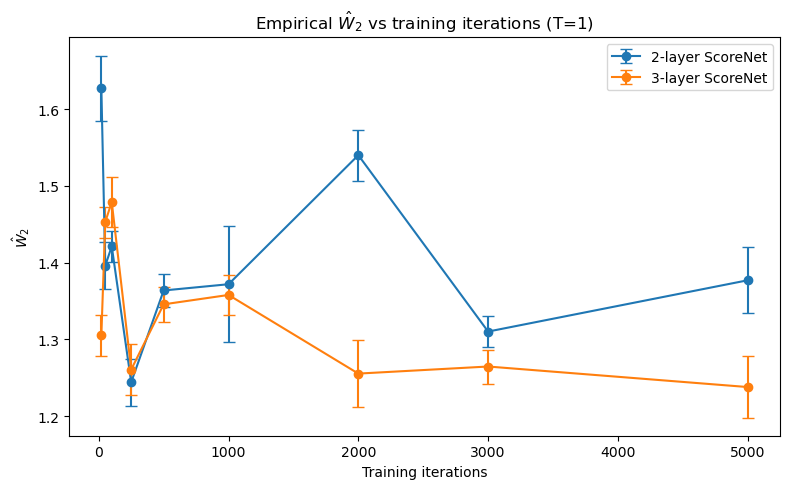

In [12]:
results_T1 = fct.load_results("outputs/results_T1.pt")
fct.plot_W2_curve(results_T1, title_suffix="(T=1)")

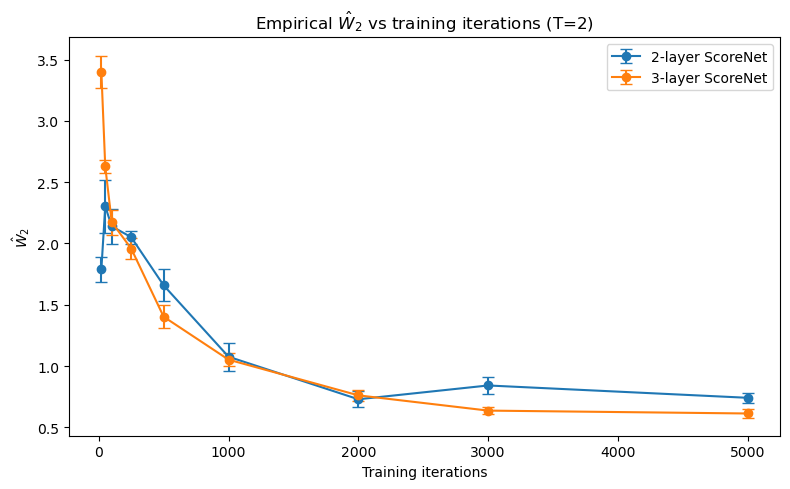

In [10]:
results_T2 = fct.load_results("outputs/results_T2.pt")
fct.plot_W2_curve(results_T2, title_suffix="(T=2)")

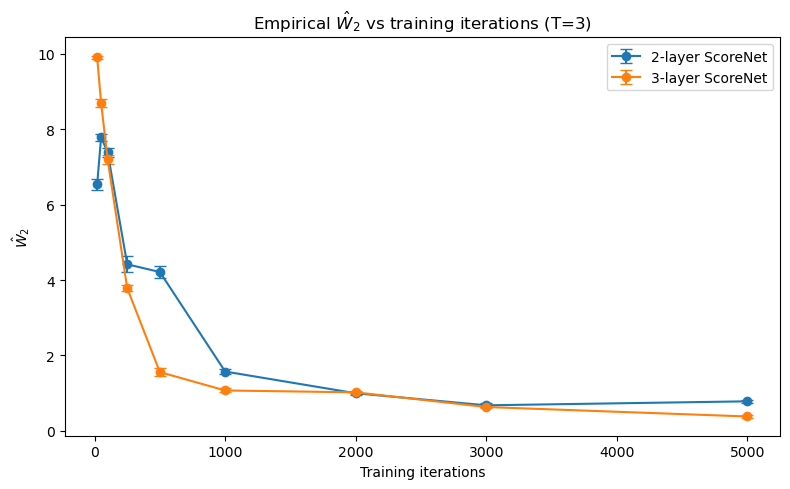

In [14]:
results_T3 = fct.load_results("outputs/results_T3.pt")
fct.plot_W2_curve(results_T3, title_suffix="(T=3)")

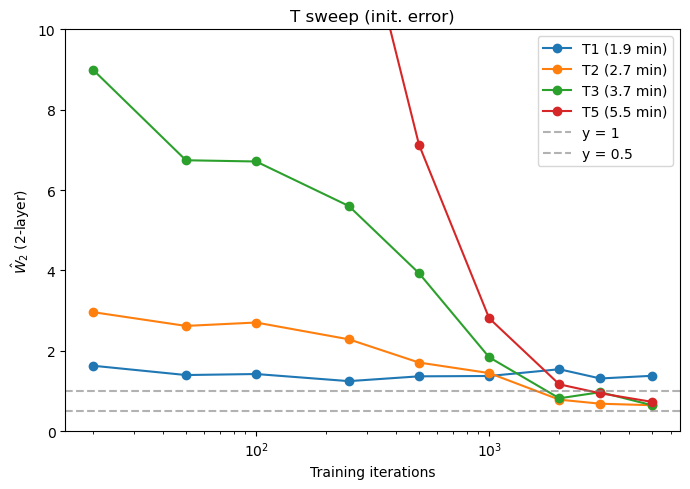

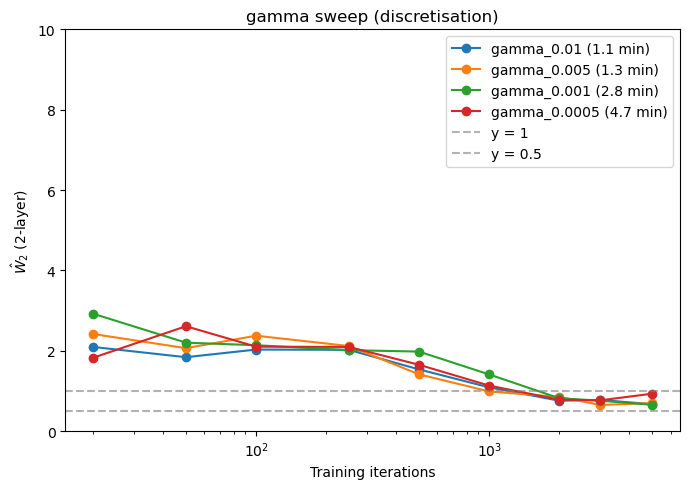

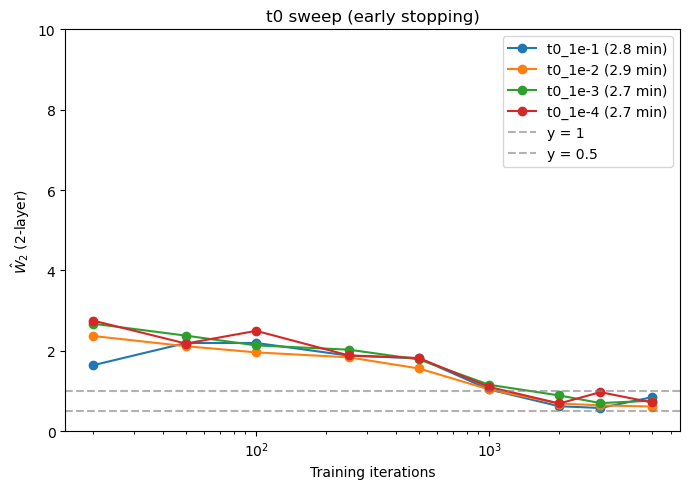

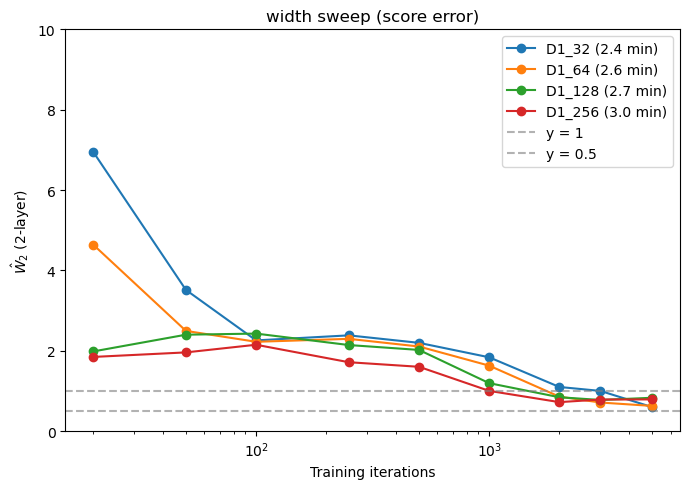

In [17]:
import functions2 as fct
import matplotlib.pyplot as plt

groups = {
    "T sweep (init. error)": ["T1", "T2", "T3", "T5"],
    "gamma sweep (discretisation)": ["gamma_0.01", "gamma_0.005", "gamma_0.001", "gamma_0.0005"],
    "t0 sweep (early stopping)": ["t0_1e-1", "t0_1e-2", "t0_1e-3", "t0_1e-4"],
    "width sweep (score error)": ["D1_32", "D1_64", "D1_128", "D1_256"],
}

all_results = {}
for group_name, tags in groups.items():
    all_results[group_name] = {tag: fct.load_results(f"outputs/results_{tag}.pt") for tag in tags}

for group_name, results_by_tag in all_results.items():
    plt.figure(figsize=(7, 5))
    for tag, results in results_by_tag.items():
        runtime = results.get("runtime_seconds")
        label = f"{tag}" + (f" ({runtime/60:.1f} min)" if runtime else "")
        plt.plot(results["checkpoints"], results["W2_2layer_curve"], marker='o', label=label)

    plt.axhline(y=1, linestyle='--', color='gray', alpha=0.6, label='y = 1')
    plt.axhline(y=0.5, linestyle='--', color='gray', alpha=0.6, label='y = 0.5')

    plt.xlabel("Training iterations")
    plt.ylabel(r"$\hat{W}_2$ (2-layer)")
    plt.xscale('log')
    plt.ylim(0, 10)
    plt.title(group_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
import functions2 as fct
import numpy as np

fct.set_seed(0)
device = fct.get_device()

d = 2
mu1, mu2 = np.array([1.3, 1.3]), np.array([-1.3, -1.3])
X_data_bimodal = fct.sample_bimodal_data(N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=1.0, weight=0.5)

iter 500/5000, loss = 1.4115
iter 1000/5000, loss = 1.3983
iter 1500/5000, loss = 1.0579
iter 2000/5000, loss = 1.0829
iter 2500/5000, loss = 4.0778
iter 3000/5000, loss = 1.2927
iter 3500/5000, loss = 1.3896
iter 4000/5000, loss = 2.9360
iter 4500/5000, loss = 1.6492
iter 5000/5000, loss = 1.2708


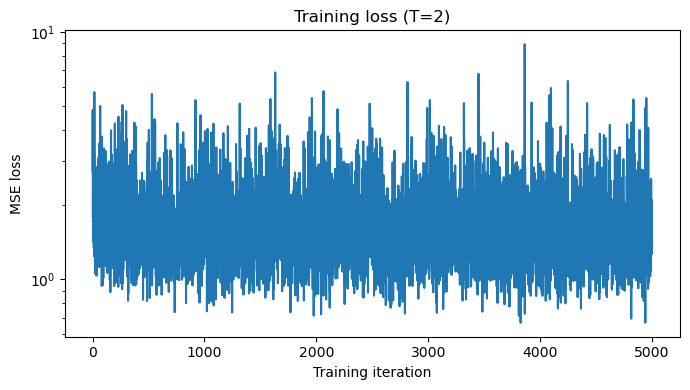

In [7]:
# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
T = 2
net = fct.ScoreNet(d=d, D_1=128)  # swap for fct.ScoreNet3(d=d, D_1=128, D_2=128) to try the 3-layer net

net, loss_history = fct.train_network(
    net, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=5000, batch_size=512, lr=1e-3, device=device, print_every=500
)

fct.plot_loss_curve(loss_history, title_suffix=f"(T={T})")

In [11]:
# ------------------------------------------------------------
# Sample
# ------------------------------------------------------------
N_samples = 1_000_000
samples = fct.euler_maruyama_sample_nn_batch(
    net, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

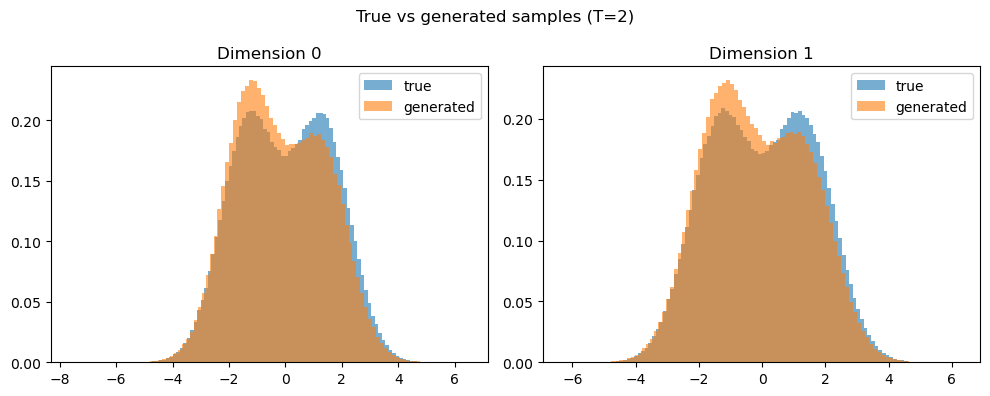

In [12]:
# ------------------------------------------------------------
# Display: true distribution vs generated samples
# ------------------------------------------------------------
fct.plot_true_vs_generated(X_data_bimodal, samples, d=d, title_suffix=f"(T={T})")

In [42]:
# ------------------------------------------------------------
# Wasserstein-2 distance
# ------------------------------------------------------------
N_w2 = 2000
w2 = fct.wasserstein2_distance(samples[:N_w2], X_data_bimodal[:N_w2])
print(f"W2(generated, true) = {w2:.4f}")

W2(generated, true) = 0.4037


In [43]:
import functions3 as fct
import numpy as np
import matplotlib.pyplot as plt

results = fct.load_results("outputs/gridsearch3_results.pt")
print(f"{len(results)} configs loaded")

36 configs loaded


In [44]:
# ------------------------------------------------------------

# True data, and the W2 noise floor: the W2 distance between two
# INDEPENDENT samples, both drawn from the true pi_D. This is the
# minimum W2 achievable by any network at this sample size - it's
# finite-sample estimator bias, not model error, so no amount of
# training can beat it.
# ------------------------------------------------------------
d = 2
mu1 = np.array([1.3, 1.3])
mu2 = np.array([-1.3, -1.3])
sigma_mix = 1.0
weight = 0.5

X_data_bimodal = fct.sample_bimodal_data(
    N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)

w2_floor_mean, w2_floor_std = fct.W2_self_floor(X_data_bimodal, N=2000, n_repeats=5)
print(f"W2 noise floor (N=2000): {w2_floor_mean:.4f} ± {w2_floor_std:.4f}")

W2 noise floor (N=2000): 0.1977 ± 0.0202


In [45]:
# 5 LAYER
ranked = sorted(results.items(), key=lambda kv: kv[1]["w2_mean"])

print(f"{'tag':45s} {'W2':>18s} {'final_loss':>12s}")
for tag, r in ranked:
    print(f"{tag:45s} {r['w2_mean']:.4f} ± {r['w2_std']:.4f}  {r['final_loss']:12.4f}")

best_tag = ranked[0][0]
print(f"\nBest config: {best_tag}")

tag                                                           W2   final_loss
theopoula_lam0.02_eps0.2_beta1e+10_r2         0.1905 ± 0.0154        0.6857
theopoula_lam0.02_eps0.1_beta1e+10_r1.5       0.1994 ± 0.0228        0.6859
theopoula_lam0.01_eps0.1_beta1e+10_r0         0.2005 ± 0.0102        0.6845
theopoula_lam0.005_eps0.2_beta1e+12_r0        0.2038 ± 0.0057        0.6858
theopoula_lam0.02_eps0.1_beta1e+10_r2         0.2116 ± 0.0160        0.6864
theopoula_lam0.01_eps0.2_beta1e+12_r2         0.2182 ± 0.0132        0.6877
theopoula_lam0.005_eps0.2_beta1e+10_r1.5      0.2205 ± 0.0068        0.6861
theopoula_lam0.02_eps0.2_beta1e+10_r1.5       0.2227 ± 0.0111        0.6846
theopoula_lam0.02_eps0.1_beta1e+12_r2         0.2234 ± 0.0186        0.6860
theopoula_lam0.01_eps0.1_beta1e+12_r1.5       0.2263 ± 0.0233        0.6867
theopoula_lam0.005_eps0.1_beta1e+12_r2        0.2300 ± 0.0271        0.6848
theopoula_lam0.005_eps0.1_beta1e+10_r1.5      0.2307 ± 0.0183        0.6852
theopoula_

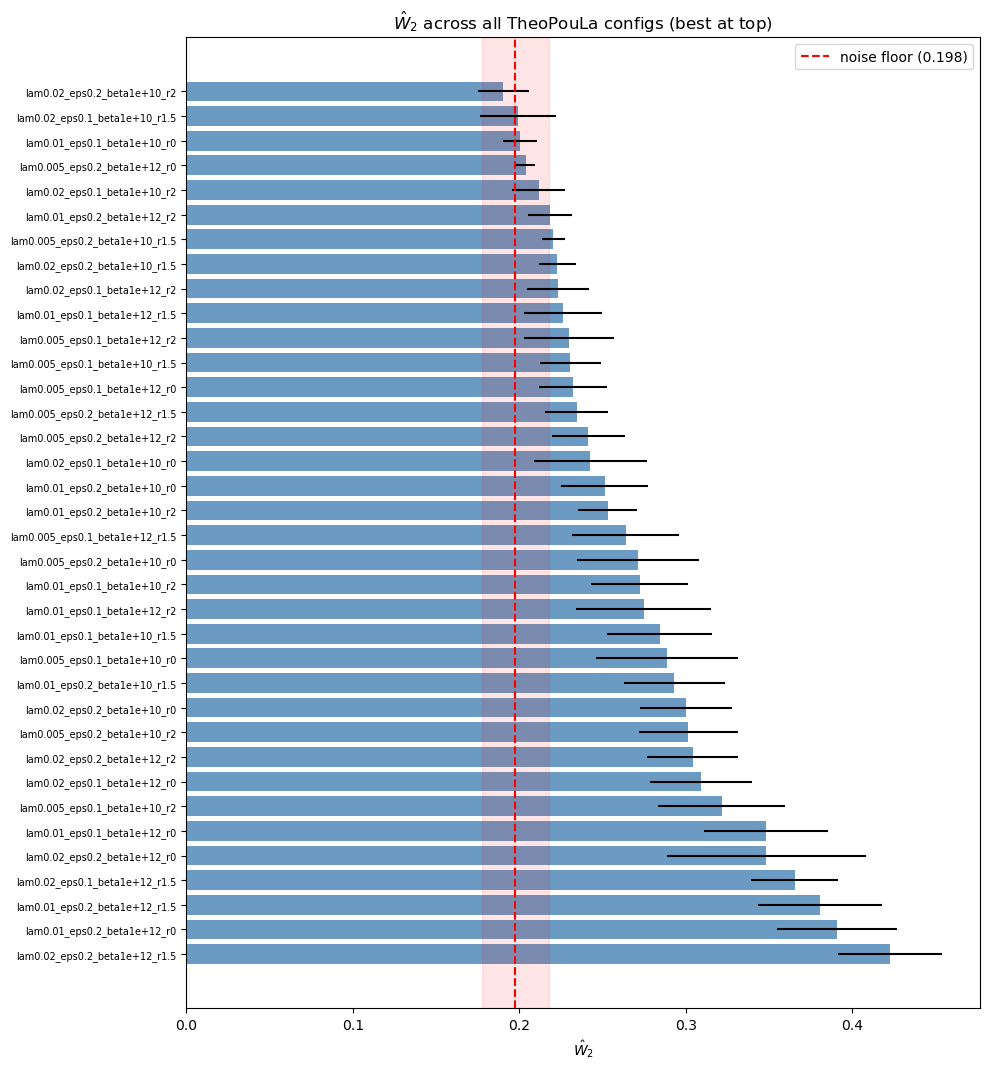

In [46]:
# 5 LAYER
tags = [tag for tag, _ in ranked]
means = [r["w2_mean"] for _, r in ranked]
stds = [r["w2_std"] for _, r in ranked]

plt.figure(figsize=(10, max(6, 0.3 * len(tags))))
plt.barh(range(len(tags)), means, xerr=stds, color="steelblue", alpha=0.8)
plt.axvline(w2_floor_mean, color="red", linestyle="--", label=f"noise floor ({w2_floor_mean:.3f})")
plt.axvspan(w2_floor_mean - w2_floor_std, w2_floor_mean + w2_floor_std, color="red", alpha=0.1)
plt.yticks(range(len(tags)), [t.replace("theopoula_", "") for t in tags], fontsize=7)
plt.xlabel(r"$\hat{W}_2$")
plt.title(r"$\hat{W}_2$ across all TheoPouLa configs (best at top)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

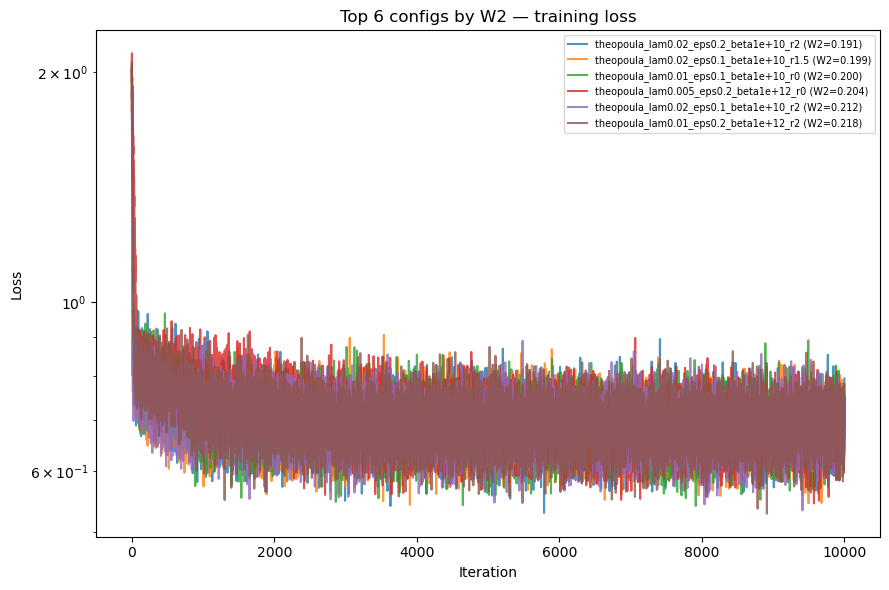

In [47]:
# 5 LAYER
top_n = 6
plt.figure(figsize=(9, 6))
for tag, r in ranked[:top_n]:
    plt.plot(r["loss_history"], label=f"{tag} (W2={r['w2_mean']:.3f})", alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title(f"Top {top_n} configs by W2 — training loss")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

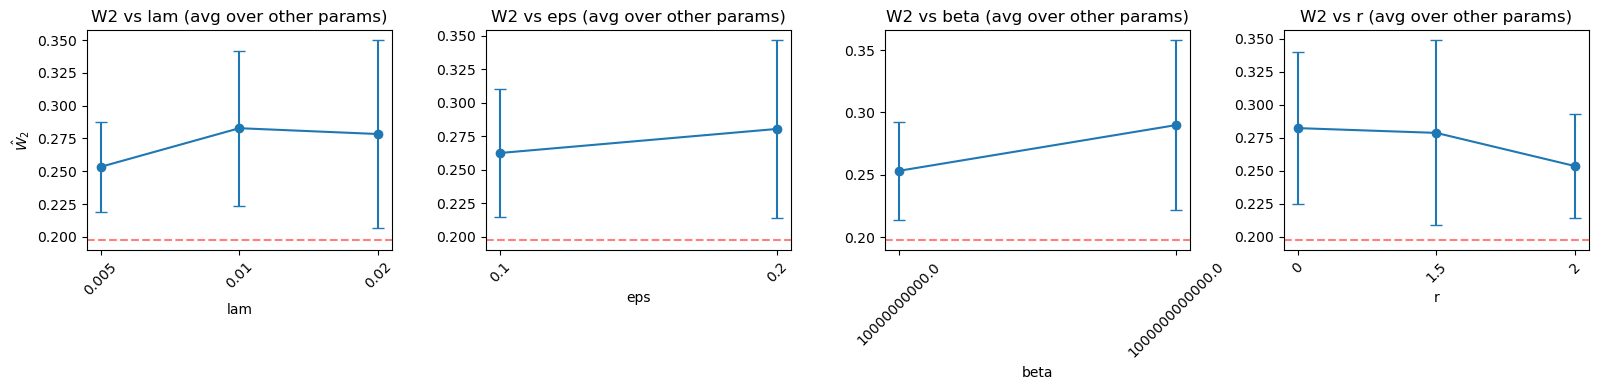

In [48]:
# 5 LAYER
config_keys = ["lam", "eps", "beta", "r"]

fig, axes = plt.subplots(1, len(config_keys), figsize=(4 * len(config_keys), 4))
for ax, key in zip(axes, config_keys):
    grouped = {}
    for tag, r in results.items():
        val = r["config"][key]
        grouped.setdefault(val, []).append(r["w2_mean"])

    xs = sorted(grouped.keys())
    means = [np.mean(grouped[x]) for x in xs]
    stds = [np.std(grouped[x]) for x in xs]

    ax.errorbar(range(len(xs)), means, yerr=stds, marker="o", capsize=4)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([str(x) for x in xs], rotation=45)
    ax.axhline(w2_floor_mean, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel(key)
    ax.set_title(f"W2 vs {key} (avg over other params)")
axes[0].set_ylabel(r"$\hat{W}_2$")
plt.tight_layout()
plt.show()

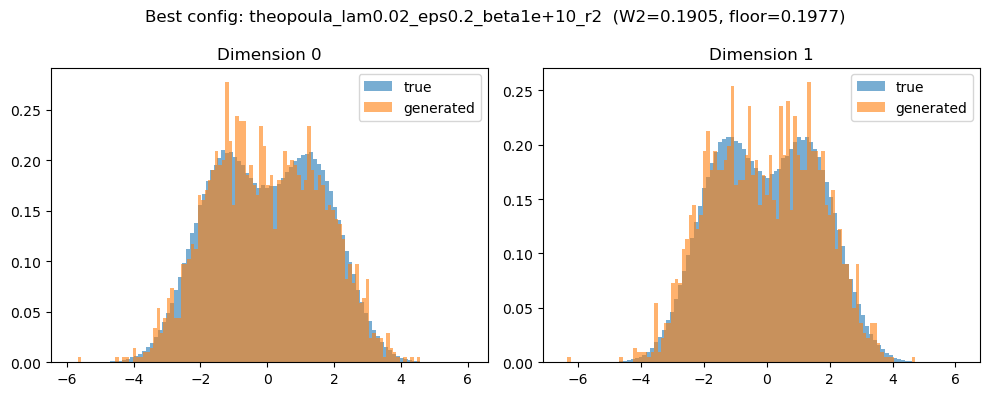

In [49]:
# 5 LAYER
best_res = results[best_tag]
samples_best = best_res["samples"]

fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, label="true", density=True)
    axes[i].hist(samples_best[:, i], bins=100, alpha=0.6, label="generated", density=True)
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle(f"Best config: {best_tag}  (W2={best_res['w2_mean']:.4f}, floor={w2_floor_mean:.4f})")
plt.tight_layout()
plt.show()

In [50]:
# ------------------------------------------------------------
# 5 LAYER
# Sample 200,000 points from the best config's trained network,
# for a much less noisy visual comparison than the 2000 points
# saved during the grid search.
# ------------------------------------------------------------
device = fct.get_device()

best_tag = "theopoula_lam0.02_eps0.2_beta1e+10_r2"   # best by W2 from the ranked table
best_config = results[best_tag]["config"]

net_best = fct.ScoreNetDeep(d=d, hidden_dims=[128] * 4).to(device)
net_best.load_state_dict(results[best_tag]["net_state"])

samples_best_200k = fct.euler_maruyama_sample_nn_batch(
    net_best, gamma=0.001, T=2, d=d, N_samples=200_000, device=device
)

print(f"Sampled {samples_best_200k.shape[0]} points from {best_tag}")

Sampled 200000 points from theopoula_lam0.02_eps0.2_beta1e+10_r2


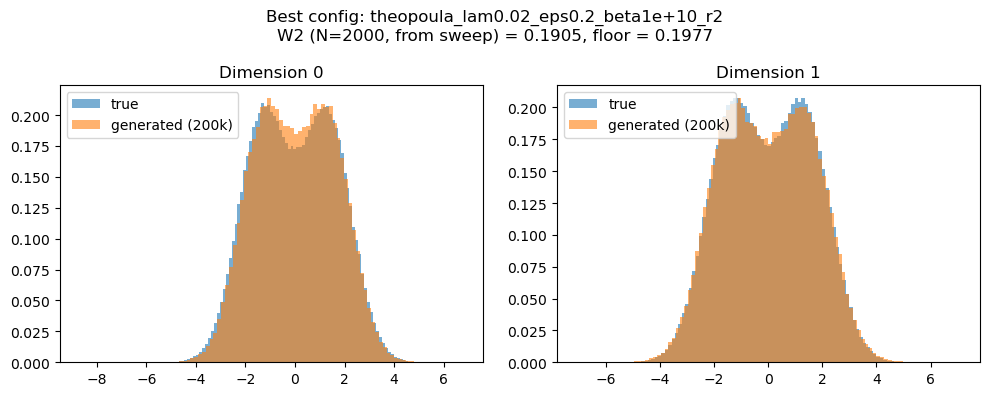

In [51]:
# ------------------------------------------------------------
# 5 LAYER
# True vs generated, using the 200k-sample draw for a smoother
# comparison than the 2000-point version stored during the sweep.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, label="true", density=True)
    axes[i].hist(samples_best_200k[:, i], bins=100, alpha=0.6, label="generated (200k)", density=True)
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle(f"Best config: {best_tag}\nW2 (N=2000, from sweep) = {results[best_tag]['w2_mean']:.4f}, floor = {w2_floor_mean:.4f}")
plt.tight_layout()
plt.show()

iter   1: loss = 2.0536
iter   2: loss = 1.9283
iter   3: loss = 1.7581
iter   4: loss = 1.7272
iter   5: loss = 1.7755
iter   6: loss = 1.6531
iter   7: loss = 1.6320
iter   8: loss = 1.4154
iter   9: loss = 1.2941
iter  10: loss = 1.1859
iter  11: loss = 1.0553
iter  12: loss = 1.1163
iter  13: loss = 0.9885
iter  14: loss = 0.9660
iter  15: loss = 0.9718
iter  16: loss = 0.9555
iter  17: loss = 0.8874
iter  18: loss = 0.8797
iter  19: loss = 0.8336
iter  20: loss = 0.8855
iter  21: loss = 0.8119
iter  22: loss = 0.8043
iter  23: loss = 0.9412
iter  24: loss = 0.8170
iter  25: loss = 0.7894
iter  26: loss = 0.9493
iter  27: loss = 0.7951
iter  28: loss = 0.7945
iter  29: loss = 0.8490
iter  30: loss = 0.9089
iter  31: loss = 0.7317
iter  32: loss = 0.7951
iter  33: loss = 0.7937
iter  34: loss = 0.8459
iter  35: loss = 0.8157
iter  36: loss = 0.7779
iter  37: loss = 0.7867
iter  38: loss = 0.8544
iter  39: loss = 0.9216
iter  40: loss = 0.7639
iter  41: loss = 0.8099
iter  42: loss =

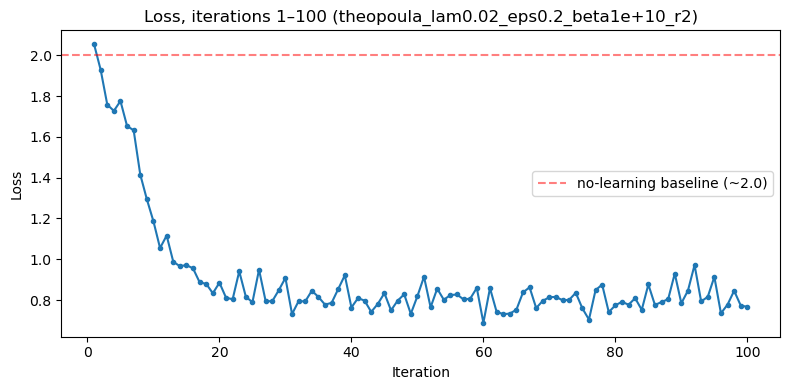

In [52]:
# checking the first 100 training losses for the best config
# 5 LAYER
best_tag = "theopoula_lam0.02_eps0.2_beta1e+10_r2"
loss_history = results[best_tag]["loss_history"]

for it, loss in enumerate(loss_history[:100], start=1):
    print(f"iter {it:3d}: loss = {loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), loss_history[:100], marker='o', markersize=3)
plt.axhline(2.0, color='red', linestyle='--', alpha=0.5, label='no-learning baseline (~2.0)')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"Loss, iterations 1–100 ({best_tag})")
plt.legend()
plt.tight_layout()
plt.show()